# PhoBERT Baseline - Cross Entropy Loss

## Mô tả
Notebook này triển khai mô hình PhoBERT baseline cho phân tích cảm xúc sinh viên.

**Đặc điểm:**
- Sử dụng PhoBERT pre-trained (vinai/phobert-base)
- Loss function: CrossEntropyLoss (standard)
- Không sử dụng data augmentation
- Không sử dụng class weights

**Mục đích:** Làm baseline để so sánh với các phương pháp cải tiến.

## 1. Setup và Import Libraries

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
!pip install transformers torch scikit-learn matplotlib seaborn

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [23]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

## 2. Configuration

In [24]:
class Config:
    BASE_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis'
    DATA_DIR = f'{BASE_DIR}/data/processed'
    # NEW: Hierarchical results directory structure
    # Format: results/{ModelType}/{baseline|improvements}/
    MODEL_TYPE = 'PhoBERT'
    EXPERIMENT_TYPE = 'baseline'  # Baseline has no timestamp
    RESULTS_DIR = f'{BASE_DIR}/results/{MODEL_TYPE}/{EXPERIMENT_TYPE}'

    MODEL_NAME = 'vinai/phobert-base'
    MAX_LENGTH = 256
    BATCH_SIZE = 16
    LEARNING_RATE = 2e-5
    NUM_EPOCHS = 5
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    EARLY_STOPPING_PATIENCE = 5
    NUM_CLASSES = 3
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Subdirectories for organized outputs
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')

config = Config()
# Create all subdirectories
for dir_path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR,
                 config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

print(f'Results will be saved to: {config.RESULTS_DIR}')
print(f'Device: {config.DEVICE}')
print(f'Structure: models/, summaries/, visualizations/, artifacts/')

Results will be saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT/baseline
Device: cuda
Structure: models/, summaries/, visualizations/, artifacts/


## 3. Load Data

In [25]:
def load_data(data_dir, split):
    split_dir = os.path.join(data_dir, split)
    with open(os.path.join(split_dir, 'sents.txt'), 'r', encoding='utf-8') as f:
        texts = [line.strip() for line in f.readlines()]
    with open(os.path.join(split_dir, 'sentiments.txt'), 'r', encoding='utf-8') as f:
        labels = [int(line.strip()) for line in f.readlines()]
    print(f'{split}: {len(texts)} samples')
    return texts, labels

train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

train: 11426 samples
validation: 1583 samples
test: 3166 samples


In [26]:
from collections import Counter

print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}:')
    for label, count in sorted(counter.items()):
        print(f'  {config.LABEL_MAP[label]}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train:
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Val:
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test:
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. Dataset và DataLoader

In [27]:
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
print(f'Tokenizer loaded: {config.MODEL_NAME}')

Tokenizer loaded: vinai/phobert-base


In [28]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [29]:
train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, config.MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 715
Val batches: 99
Test batches: 198


## 5. Model Definition

In [30]:
class PhoBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1):
        super(PhoBERTClassifier, self).__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits

In [31]:
model = PhoBERTClassifier(model_name=config.MODEL_NAME, num_classes=config.NUM_CLASSES)
model = model.to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 135,000,579
Trainable parameters: 135,000,579


## 6. Training Setup - CrossEntropyLoss (Baseline)

In [32]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

total_steps = len(train_loader) * config.NUM_EPOCHS
warmup_steps = int(total_steps * config.WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

print('Loss function: CrossEntropyLoss (standard)')
print(f'Total training steps: {total_steps}')
print(f'Warmup steps: {warmup_steps}')

Loss function: CrossEntropyLoss (standard)
Total training steps: 3575
Warmup steps: 357


## 7. Training Functions

In [33]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    progress_bar = tqdm(dataloader, desc='Training')
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, accuracy, f1

In [34]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels


## 8. Training Loop

In [35]:
history = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0
patience_counter = 0

if 'config' not in globals():
    if 'Config' not in globals():
        raise NameError('`config` is not defined. Run the Configuration cell first.')
    config = Config()
    for dir_path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR,
                     config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
        os.makedirs(dir_path, exist_ok=True)
    print('`config` was missing, recreated from Config().')

required_objects = ['model', 'train_loader', 'val_loader', 'criterion', 'optimizer', 'scheduler', 'train_epoch', 'evaluate']
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(f'Missing required objects for training: {missing_objects}. Run the previous setup cells first.')

print('='*60)
print('Starting Training - PhoBERT Baseline (CrossEntropyLoss)')
print('='*60)

for epoch in range(config.NUM_EPOCHS):
    print(f'Epoch {epoch + 1}/{config.NUM_EPOCHS}')
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, scheduler, config.DEVICE)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, config.DEVICE)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    print(f'Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}')
    print(f'Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}')
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        # NEW: Save to models directory
        torch.save(model.state_dict(), os.path.join(config.MODELS_DIR, 'phobert_model.pt'))
        print(f'New best model saved! Val F1: {val_f1:.4f}')
    else:
        patience_counter += 1
        print(f'No improvement. Patience: {patience_counter}/{config.EARLY_STOPPING_PATIENCE}')
        if patience_counter >= config.EARLY_STOPPING_PATIENCE:
            print(f'Early stopping triggered at epoch {epoch + 1}')
            break

print('='*60)
print(f'Training completed! Best Val F1: {best_val_f1:.4f}')
print('='*60)

Starting Training - PhoBERT Baseline (CrossEntropyLoss)
Epoch 1/5


Evaluating: 100%|██████████| 99/99 [00:20<00:00,  4.86it/s]


Train - Loss: 0.4281, Acc: 0.8341, F1: 0.8251
Val   - Loss: 0.2293, Acc: 0.9362, F1: 0.9331
New best model saved! Val F1: 0.9331
Epoch 2/5


Evaluating: 100%|██████████| 99/99 [00:20<00:00,  4.88it/s]


Train - Loss: 0.2054, Acc: 0.9382, F1: 0.9356
Val   - Loss: 0.2774, Acc: 0.9337, F1: 0.9255
No improvement. Patience: 1/5
Epoch 3/5


...

Train - Loss: 0.1462, Acc: 0.9597, F1: 0.9588
Val   - Loss: 0.2574, Acc: 0.9413, F1: 0.9363
New best model saved! Val F1: 0.9363
Epoch 4/5


Evaluating: 100%|██████████| 99/99 [00:20<00:00,  4.89it/s]


Train - Loss: 0.1003, Acc: 0.9733, F1: 0.9730
Val   - Loss: 0.2599, Acc: 0.9450, F1: 0.9441
New best model saved! Val F1: 0.9441
Epoch 5/5


Evaluating: 100%|██████████| 99/99 [00:20<00:00,  4.87it/s]


Train - Loss: 0.0787, Acc: 0.9797, F1: 0.9795
Val   - Loss: 0.2757, Acc: 0.9469, F1: 0.9455
New best model saved! Val F1: 0.9455
Training completed! Best Val F1: 0.9455


## 9. Training Visualization

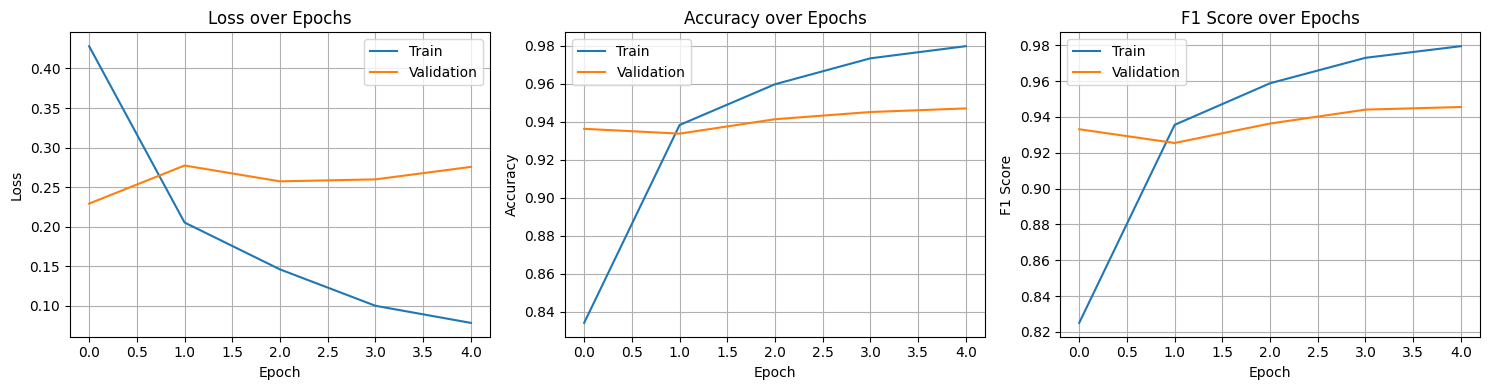

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)
axes[2].plot(history['train_f1'], label='Train')
axes[2].plot(history['val_f1'], label='Validation')
axes[2].set_title('F1 Score over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True)
plt.tight_layout()
# NEW: Save to visualizations directory
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'training_history.png'), dpi=150)
plt.show()

## 10. Evaluation on Test Set

In [37]:
# NEW: Load from models directory
model.load_state_dict(torch.load(os.path.join(config.MODELS_DIR, 'phobert_model.pt')))
print('Best model loaded for evaluation')

test_loss, test_acc, test_precision, test_recall, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, config.DEVICE)

print('='*60)
print('TEST SET RESULTS - PhoBERT Baseline (CrossEntropyLoss)')
print('='*60)
print(f'Loss: {test_loss:.4f}')
print(f'Accuracy: {test_acc:.4f}')
print(f'Precision (weighted): {test_precision:.4f}')
print(f'Recall (weighted): {test_recall:.4f}')
print(f'F1 Score (weighted): {test_f1:.4f}')


Best model loaded for evaluation


Evaluating: 100%|██████████| 198/198 [00:41<00:00,  4.76it/s]

TEST SET RESULTS - PhoBERT Baseline (CrossEntropyLoss)
Loss: 0.3165
Accuracy: 0.9324
F1 Score (weighted): 0.9307


In [38]:
print('Classification Report:')
target_names = [config.LABEL_MAP[i] for i in range(config.NUM_CLASSES)]
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9413    0.9553    0.9482      1409
     Neutral     0.6423    0.5269    0.5789       167
    Positive     0.9493    0.9547    0.9520      1590

    accuracy                         0.9324      3166
   macro avg     0.8443    0.8123    0.8264      3166
weighted avg     0.9296    0.9324    0.9307      3166



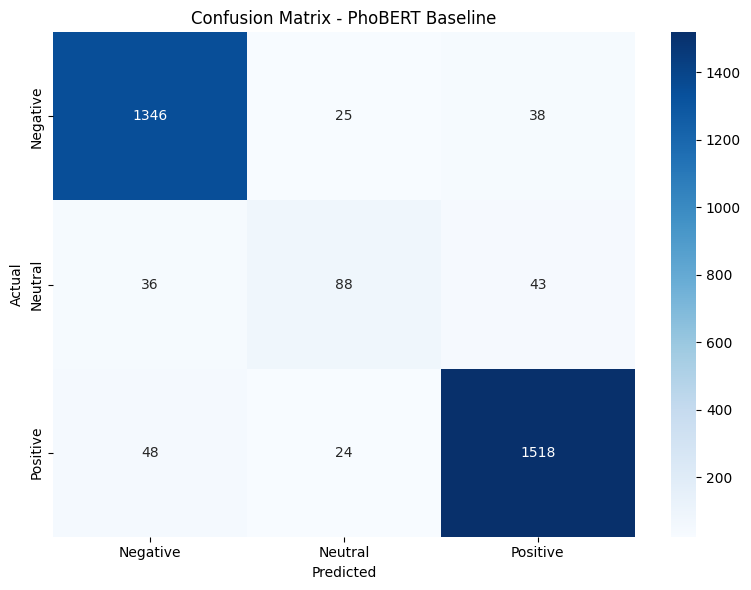

In [39]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - PhoBERT Baseline')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
# NEW: Save to visualizations directory
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## 11. Save Results

In [40]:
import pandas as pd

summary = {
    'Model': 'PhoBERT Baseline',
    'Loss Function': 'CrossEntropyLoss',
    'Data Augmentation': 'No',
    'Class Weights': 'No',
    'Epochs Trained': len(history['train_loss']),
    'Best Val F1': best_val_f1,
    'Test Accuracy': test_acc,
    'Test Precision (weighted)': test_precision,
    'Test Recall (weighted)': test_recall,
    'Test F1 (weighted)': test_f1,
    'Test Loss': test_loss
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'summary.csv'), index=False)

print('='*60)
print('SAVING RESULTS')
print('='*60)
print('Results Summary:')
for key, value in summary.items():
    if isinstance(value, float):
        print(f'{key}: {value:.4f}')
    else:
        print(f'{key}: {value}')

print(f'\nAll results saved to: {config.RESULTS_DIR}')
print('  - models/phobert_model.pt')
print('  - summaries/summary.csv')
print('  - visualizations/training_history.png, confusion_matrix.png')


💾 SAVING RESULTS
Results Summary:
Model: PhoBERT Baseline
Loss Function: CrossEntropyLoss
Data Augmentation: No
Class Weights: No
Epochs Trained: 5
Best Val F1: 0.9455
Test Accuracy: 0.9324
Test F1 (weighted): 0.9307
Test Loss: 0.3165

📁 All results saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT/baseline
   ├── models/phobert_model.pt
   ├── summaries/summary.csv
   └── visualizations/training_history.png, confusion_matrix.png


## 12. Summary

### PhoBERT Baseline Model

**Configuration:**
- Model: vinai/phobert-base
- Loss: CrossEntropyLoss (standard)
- No data augmentation
- No class weights
- Epochs: 10 (with early stopping)

**Purpose:**
This baseline model serves as a reference point for comparing with enhanced versions like:
- PhoBERT + Focal Loss
- PhoBERT + Data Augmentation
- PhoBERT + Class Weights